Hunting for a massive cascade to photograph...
Mega-Cascade found at step 1! Size: 499


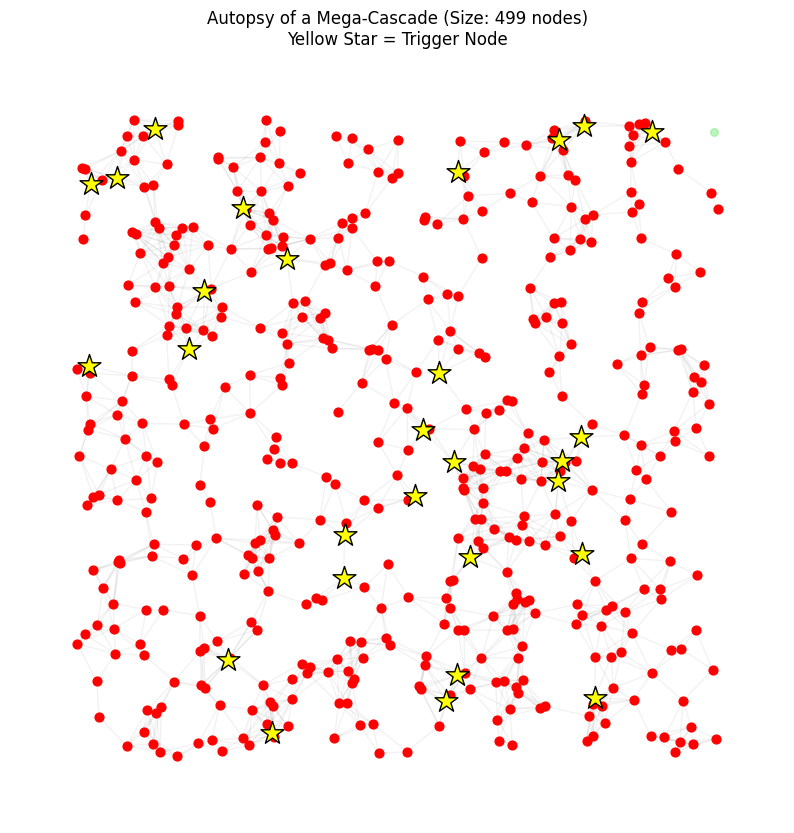

In [5]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def spatial_autopsy(NUM_NODES=500, RADIUS=0.07, TOL=0.15, NOISE=0.8):
    # Using 500 nodes so the visual map isn't too cluttered
    G = nx.random_geometric_graph(NUM_NODES, radius=RADIUS)
    pos = nx.get_node_attributes(G, 'pos') # Physical coordinates

    for node in G.nodes():
        load = np.random.uniform(0, 10)
        G.nodes[node]['load'] = load
        G.nodes[node]['capacity'] = load * (1 + TOL)
        G.nodes[node]['tripped'] = False

    print("Hunting for a massive cascade to photograph...")
    step = 0
    while True:
        step += 1
        for node in G.nodes(): G.nodes[node]['load'] += (NOISE / 10.0)

        # Identify patient zeros before they trip
        patient_zeros = [n for n, d in G.nodes(data=True) if d['load'] > d['capacity'] and not d['tripped']]

        current_avalanche = []

        while True:
            overloaded = [n for n, d in G.nodes(data=True) if d['load'] > d['capacity'] and not d['tripped']]
            if not overloaded: break

            for node in overloaded:
                overload_amt = G.nodes[node]['load']
                G.nodes[node]['load'] = 0
                G.nodes[node]['tripped'] = True
                current_avalanche.append(node)

                active_nbrs = [nbr for nbr in G.neighbors(node) if not G.nodes[nbr]['tripped']]
                if active_nbrs:
                    spill = overload_amt / len(active_nbrs)
                    for nbr in active_nbrs: G.nodes[nbr]['load'] += spill

        # If the avalanche destroyed more than 20% of the grid, stop and plot!
        if len(current_avalanche) > (NUM_NODES * 0.20):
            print(f"Mega-Cascade found at step {step}! Size: {len(current_avalanche)}")

            plt.figure(figsize=(10, 10))

            # Draw lines
            nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')

            # Draw safe nodes
            safe_nodes = [n for n in G.nodes() if n not in current_avalanche]
            nx.draw_networkx_nodes(G, pos, nodelist=safe_nodes, node_color='lightgreen', node_size=30, alpha=0.6)

            # Draw failed nodes
            nx.draw_networkx_nodes(G, pos, nodelist=current_avalanche, node_color='red', node_size=40)

            # Draw Patient Zero(s)
            nx.draw_networkx_nodes(G, pos, nodelist=patient_zeros, node_color='yellow', node_shape='*', node_size=300, edgecolors='black')

            plt.title(f"Autopsy of a Mega-Cascade (Size: {len(current_avalanche)} nodes)\nYellow Star = Trigger Node")
            plt.axis('off')
            plt.show()
            return # Exit function

        for node in G.nodes(): G.nodes[node]['tripped'] = False

# --- PLOTTING ---
# Run it! It will loop silently until it catches a big one.
spatial_autopsy()